# Exercises — Image Representation in Python

In this notebook you will practice the most common operations on digital images using two of the most popular libraries in Python: **OpenCV** (`cv2`) and **Pillow** (`PIL`).

## Learning objectives
By the end of this notebook you should be able to:
1. Load an image and understand how it is represented in memory.
2. Recognize the difference between the **RGB** and **BGR** color orderings.
3. Resize and crop images using both NumPy slicing (OpenCV) and Pillow methods.
4. Apply a smoothing (blur) filter.
5. Draw shapes and text annotations on top of an image.
6. Convert an image to grayscale and apply a threshold for basic segmentation.

## Instructions
- Each section contains a short description and a code cell with `# Your code here` placeholders or commented hints (`# variable = ?`).
- Replace the placeholders with your own implementation. **Do not delete the visualization code** — it lets you check your result visually.
- You can use the image `arenal.jpg` provided with the notebook, or any other `.jpg` / `.png` of your choice (just update the filename).
- If you get stuck, check the official documentation:
  - OpenCV: <https://docs.opencv.org/4.x/>
  - Pillow: <https://pillow.readthedocs.io/en/stable/>

> 💡 **Tip:** Run cells in order. Many later exercises depend on variables defined in earlier cells (e.g. `img_cv_correcta`, `img_pil`).

In [ ]:
# Core libraries used throughout the notebook.
# If any import fails, run:  pip install -r requirements.txt
import cv2                      # OpenCV
import numpy as np              # NumPy — n-dimensional arrays
import matplotlib.pyplot as plt # Matplotlib — to display images inside the notebook
from PIL import Image           # Pillow — you may need to import additional submodules later

# Path to the image we will work with. Change it if you want to try another one.
IMAGE_PATH = "arenal.jpg"

## 1. Loading an image — RGB vs BGR

Both OpenCV and Pillow can read the same `.jpg` file, but they **do not store the colors in the same order**:

| Library | Channel order | Returned type |
| ------- | ------------- | ------------- |
| OpenCV (`cv2`) | **B, G, R** | `numpy.ndarray` |
| Pillow (`PIL`) | **R, G, B** | `PIL.Image.Image` |

Matplotlib's `imshow` expects **RGB**, so if you display an OpenCV image directly the red and blue channels will look swapped (e.g. blue sky → orange sky).

### Your task
1. Load the image with **OpenCV** into `img_cv`.
2. Convert it to RGB and store the result in `img_cv_correcta`.
3. Load the same image with **Pillow** into `img_pil`.
4. Run the visualization cell and compare the three outputs.

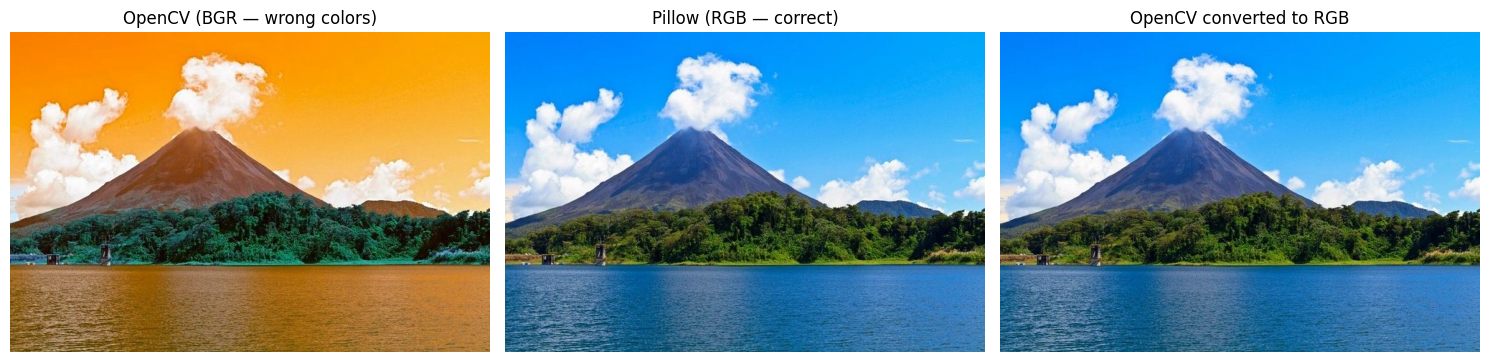

In [6]:
# --- OPENCV ---
img_cv = cv2.imread(IMAGE_PATH)                          # loads the image as a BGR NumPy array
img_cv_correcta = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB) # reorder channels to RGB

# --- PILLOW ---
img_pil = Image.open(IMAGE_PATH)                          # opens the image directly as RGB


# --- Visualization (do not modify) ---
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_cv)
ax[0].set_title("OpenCV (BGR — wrong colors)")
ax[1].imshow(img_pil)
ax[1].set_title("Pillow (RGB — correct)")
ax[2].imshow(img_cv_correcta)
ax[2].set_title("OpenCV converted to RGB")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

In [5]:
# Inspect the underlying data types of each object.
# OpenCV returns a NumPy ndarray; Pillow returns a PIL Image object.
print("OpenCV (raw)     :", type(img_cv),          "| shape:", img_cv.shape,          "| dtype:", img_cv.dtype)
print("OpenCV (RGB)     :", type(img_cv_correcta), "| shape:", img_cv_correcta.shape, "| dtype:", img_cv_correcta.dtype)
print("Pillow           :", type(img_pil),         "| size :", img_pil.size,           "| mode :", img_pil.mode)

OpenCV (raw)     : <class 'numpy.ndarray'> | shape: (446, 669, 3) | dtype: uint8
OpenCV (RGB)     : <class 'numpy.ndarray'> | shape: (446, 669, 3) | dtype: uint8
Pillow           : <class 'PIL.JpegImagePlugin.JpegImageFile'> | size : (669, 446) | mode : RGB


## 2. Resize and Crop

Two of the most common geometric operations:

- **Resize**: change the dimensions of the whole image (often to feed a neural network with a fixed input size).
- **Crop**: keep only a rectangular region of interest (ROI).

Remember that an OpenCV image is a NumPy array shaped `(height, width, channels)`, while a Pillow `Image` is an object with its own methods.

### Your task
- Resize each image to `300 × 200` pixels.
- Crop a rectangular region of your choice (any size, as long as it is inside the image).

Search the documentation for the appropriate function / method in each library.

In [ ]:
# Target size for the resize exercise (width, height).
NEW_WIDTH, NEW_HEIGHT = 300, 200

# --- OPENCV ---
# img_cv_resize = ?
# img_cv_crop   = ?

# --- PILLOW ---
# img_pil_resize = ?
# img_pil_crop   = ?


# --- Visualization (do not modify) ---
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_cv_correcta);  ax[0].set_title("OpenCV — original")
ax[1].imshow(img_cv_resize);    ax[1].set_title(f"OpenCV — resized ({NEW_WIDTH}x{NEW_HEIGHT})")
ax[2].imshow(img_cv_crop);      ax[2].set_title("OpenCV — cropped")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_pil);          ax[0].set_title("Pillow — original")
ax[1].imshow(img_pil_resize);   ax[1].set_title(f"Pillow — resized ({NEW_WIDTH}x{NEW_HEIGHT})")
ax[2].imshow(img_pil_crop);     ax[2].set_title("Pillow — cropped")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 3. Apply a blur (smoothing) filter

A **Gaussian blur** convolves the image with a Gaussian kernel — it averages each pixel with its neighbors, weighted by a 2D Gaussian function. The result is a smoother image, used to reduce noise before edge detection or segmentation.

### Your task
- Produce `blur_cv` (OpenCV) and `blur_pil` (Pillow) from the images of section 1.
- Try at least **two different blur strengths** and observe the effect.

⚠️ One of the two libraries requires the kernel size to be a **positive odd integer**. Find out which one (and why) while you read the docs.

In [ ]:
# --- OPENCV ---
# blur_cv = ?

# --- PILLOW ---
# blur_pil = ?


# --- Visualization (do not modify) ---
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].imshow(img_cv_correcta); ax[0, 0].set_title("OpenCV — original")
ax[0, 1].imshow(blur_cv);         ax[0, 1].set_title("OpenCV — Gaussian blur")
ax[1, 0].imshow(img_pil);         ax[1, 0].set_title("Pillow — original")
ax[1, 1].imshow(blur_pil);        ax[1, 1].set_title("Pillow — Gaussian blur")
for row in ax:
    for a in row: a.axis("off")
plt.tight_layout(); plt.show()

## 4. Drawing and annotations

A typical use case in Computer Vision is to **annotate detections** on top of an image — for example, drawing a bounding box around an object and writing its class name.

### Your task
- Draw a rectangle (any color and size) on **both** images.
- Write a short text label next to it on **both** images.
- Display the annotated results.

⚠️ Read the docs carefully: one of the libraries modifies the image **in place**, while the other returns a new object. Work on a **copy** of the original so you don't lose it.

In [ ]:
# --- OPENCV ---
canvas_cv = img_cv_correcta.copy()
# TODO: draw a rectangle on canvas_cv
# TODO: write some text on canvas_cv


# --- PILLOW ---
canvas_pil = img_pil.copy()
# TODO: draw a rectangle on canvas_pil
# TODO: write some text on canvas_pil


# --- Visualization (do not modify) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(canvas_cv);  ax[0].set_title("OpenCV — annotated")
ax[1].imshow(canvas_pil); ax[1].set_title("Pillow — annotated")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 5. Thresholding for segmentation

A **threshold** is the simplest form of segmentation: every pixel is compared with a constant value `T` and the result is a **binary image** (foreground vs background).

$$
\text{out}(x, y) = \begin{cases} 255 & \text{if } \text{gray}(x, y) > T \\ 0 & \text{otherwise} \end{cases}
$$

You must work on a **grayscale** image (single channel), otherwise the comparison is ambiguous.

### Your task
- Convert each image to grayscale → `gris_cv`, `gris_pil`.
- Apply a binary threshold of `127` → `th_cv`, `th_pil`.
- Display the original, the grayscale and the binary image side by side.

> When you call `imshow` on a single-channel image, pass `cmap="gray"` so Matplotlib doesn't apply its default colormap.

In [ ]:
THRESHOLD = 127  # try different values (e.g. 80, 127, 180) and observe the result

# --- OPENCV ---
# gris_cv = ?   # grayscale version of img_cv_correcta
# th_cv   = ?   # binary image after applying THRESHOLD to gris_cv

# --- PILLOW ---
# gris_pil = ?  # grayscale version of img_pil
# th_pil   = ?  # binary image after applying THRESHOLD to gris_pil


# --- Visualization (do not modify) ---
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax[0, 0].imshow(img_cv_correcta);          ax[0, 0].set_title("OpenCV — original")
ax[0, 1].imshow(gris_cv, cmap="gray");     ax[0, 1].set_title("OpenCV — grayscale")
ax[0, 2].imshow(th_cv,   cmap="gray");     ax[0, 2].set_title(f"OpenCV — threshold ({THRESHOLD})")
ax[1, 0].imshow(img_pil);                  ax[1, 0].set_title("Pillow — original")
ax[1, 1].imshow(gris_pil, cmap="gray");    ax[1, 1].set_title("Pillow — grayscale")
ax[1, 2].imshow(th_pil,   cmap="gray");    ax[1, 2].set_title(f"Pillow — threshold ({THRESHOLD})")
for row in ax:
    for a in row: a.axis("off")
plt.tight_layout(); plt.show()

---

## 🎯 Going further (optional)

Once you have completed the six exercises, try the following challenges. They are open-ended — there is no single correct answer.

1. **Channel split** — separate the R, G and B channels of `img_cv_correcta` and display them as three grayscale images. Which channel has the highest contrast for *this* picture, and why?
2. **Adaptive threshold** — replace the fixed `THRESHOLD = 127` of section 5 with `cv2.adaptiveThreshold`. Compare the results on images with non-uniform illumination.
3. **Save to disk** — write the annotated image of section 4 to a new file (`cv2.imwrite` / `img_pil.save`). Open it with the system viewer to confirm.
4. **Mini pipeline** — chain `resize → GaussianBlur → grayscale → threshold` in a single function `binarize(path)` that takes an image path and returns a binary NumPy array.

Hand in the notebook with all cells executed (outputs visible).